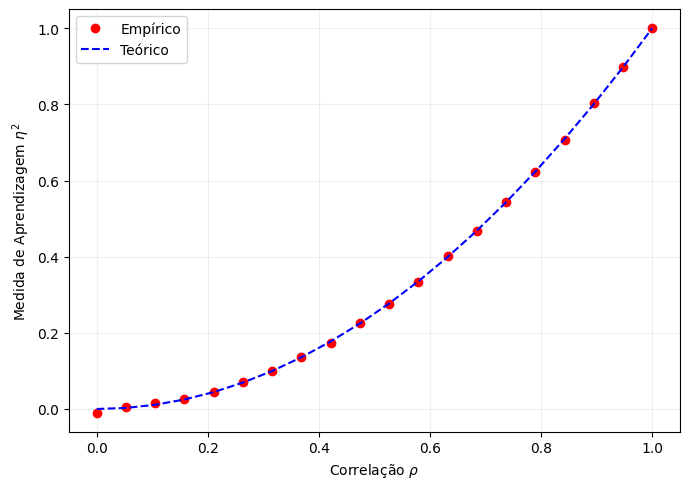

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------
# Simulation parameters
# -------------------------------------------------
n_samples = 100000
rho_values = np.linspace(0, 1.0, 20)

eta2_empirical = []
eta2_theoretical = []

# -------------------------------------------------
# Loop over different correlation levels
# -------------------------------------------------
for rho in rho_values:
    # Generate correlated normal samples (X, S)
    X = np.random.normal(0, 1, n_samples)
    noise = np.random.normal(0, np.sqrt(1 - rho**2), n_samples)
    S = rho * X + noise  # ensures corr(X,S) ≈ rho

    # Compute unconditional variance of X
    var_X = np.var(X)

    # Compute conditional variance Var(X|S)
    # For normal case, E[X|S] = rho*S
    E_X_given_S = rho * S
    var_X_given_S = (1 - rho**2) * np.ones_like(S)  # constant in normal model

    # Compute expectations
    E_var_cond = np.mean(var_X_given_S)
    # Empirical eta²
    eta2 = (var_X - E_var_cond) / var_X
    eta2_empirical.append(eta2)
    eta2_theoretical.append(rho**2)

# -------------------------------------------------
# Plot results
# -------------------------------------------------
plt.figure(figsize=(7,5))
plt.plot(rho_values, eta2_empirical, 'o', color='red', label='Empírico')
plt.plot(rho_values, eta2_theoretical, '--', color='blue', label='Teórico')
plt.xlabel(r"Correlação $\rho$")
plt.ylabel(r"Medida de Aprendizagem $\eta^2$")
#plt.title("Empirical vs. Theoretical η²(X|S) from Variance Decomposition")
plt.grid(True, alpha=0.2)
plt.legend()
plt.tight_layout()

# -------------------------------------------------
# Save the figure
# -------------------------------------------------
output_path = r"C:\Users\calva\OneDrive\Documentos\Doutorado\Proposta_de_Tese\wellington\images\eta2_empirical.png"
plt.savefig(output_path, dpi=400, bbox_inches='tight')
plt.show()


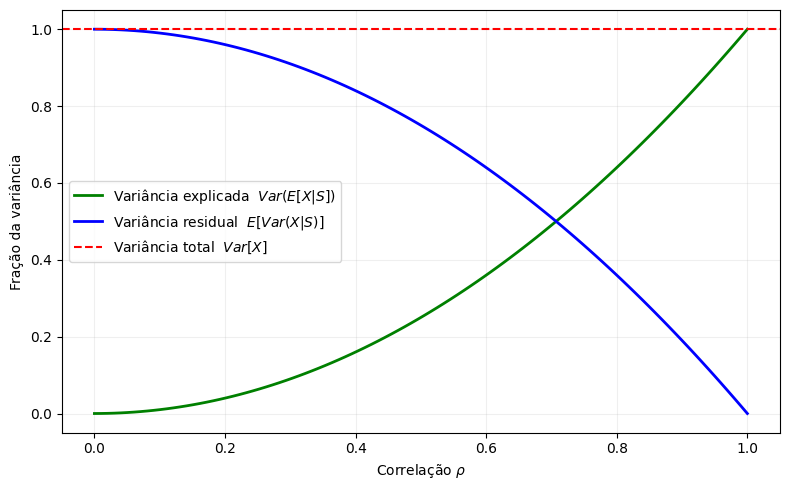

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------
# Parâmetros da simulação
# -------------------------------------------------
rho_values = np.linspace(0, 1, 100)
var_total = 1.0  # Var[X] = 1 (normalizada)
var_explained = rho_values**2
var_residual = 1 - rho_values**2

# -------------------------------------------------
# Gráfico da decomposição da variância
# -------------------------------------------------
plt.figure(figsize=(8,5))
plt.plot(rho_values, var_explained, lw=2, color="green",
         label=r"Variância explicada  $Var(E[X|S])$")
plt.plot(rho_values, var_residual, lw=2, color="blue",
         label=r"Variância residual  $E[Var(X|S)]$")
plt.axhline(1.0, color="red", linestyle="--",
            label=r"Variância total  $Var[X]$")

plt.xlabel(r"Correlação $\rho$")
plt.ylabel("Fração da variância")
# plt.title("Decomposição da Variância Total: Parte Explicada e Parte Residual")
plt.grid(True, alpha=0.2)
plt.legend()
plt.tight_layout()

# -------------------------------------------------
# Save the figure
# -------------------------------------------------
output_path = r"C:\Users\calva\OneDrive\Documentos\Doutorado\Proposta_de_Tese\wellington\images\variance_decomposition.png"
plt.savefig(output_path, dpi=400, bbox_inches='tight')
plt.show()
